In [1]:
pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.5 MB/s eta 0:00:00


In [2]:
from google.colab import files


uploaded = files.upload()

Saving 5330922-hd_1920_1080_30fps.mp4 to 5330922-hd_1920_1080_30fps.mp4



0: 384x640 14 persons, 4 bicycles, 1 car, 6 traffic lights, 190.9ms
Speed: 3.6ms preprocess, 190.9ms inference, 32.5ms postprocess per image at shape (1, 3, 384, 640)
Preview of the first frame:


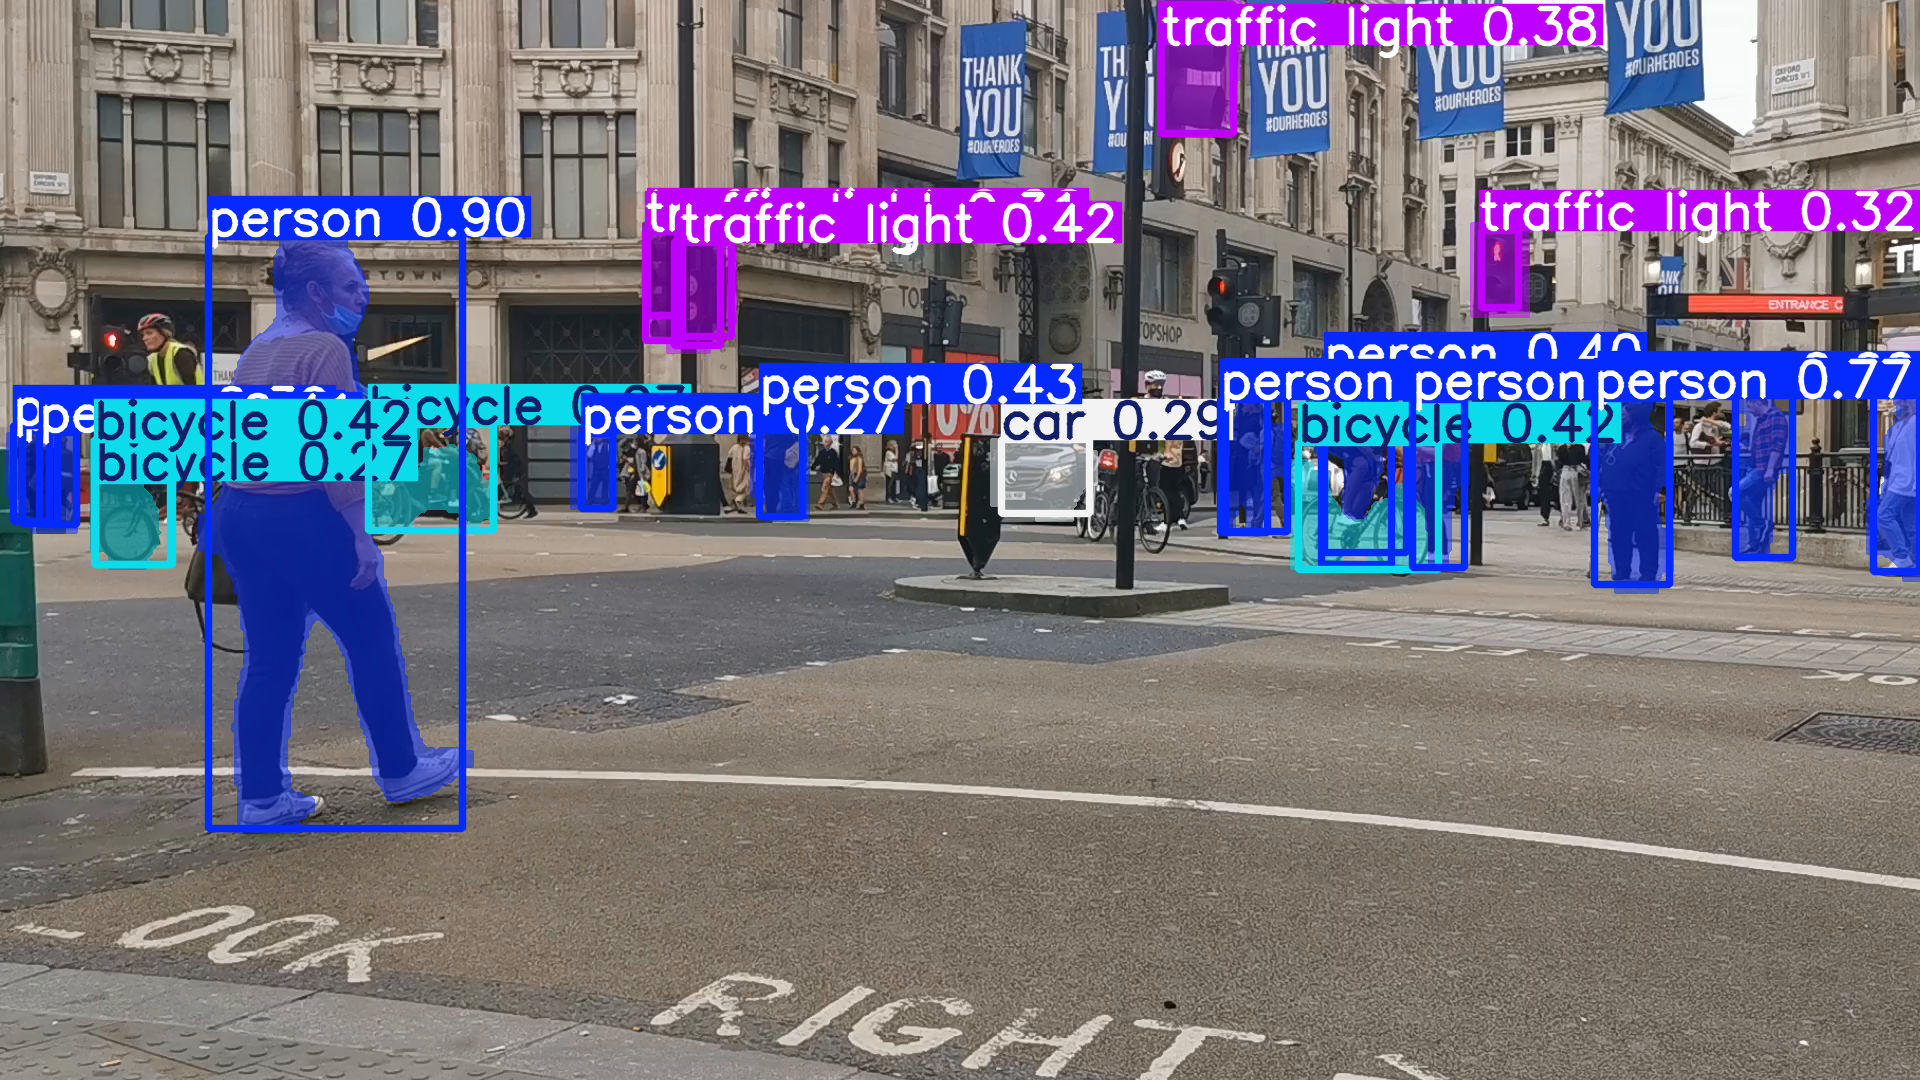


0: 384x640 14 persons, 4 bicycles, 1 car, 6 traffic lights, 244.5ms
Speed: 13.2ms preprocess, 244.5ms inference, 56.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 4 bicycles, 1 car, 6 traffic lights, 275.5ms
Speed: 15.3ms preprocess, 275.5ms inference, 28.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 18 persons, 3 bicycles, 2 cars, 6 traffic lights, 198.0ms
Speed: 5.6ms preprocess, 198.0ms inference, 30.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 2 bicycles, 2 cars, 5 traffic lights, 182.1ms
Speed: 3.9ms preprocess, 182.1ms inference, 24.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 2 bicycles, 2 cars, 5 traffic lights, 192.0ms
Speed: 3.8ms preprocess, 192.0ms inference, 27.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 2 bicycles, 2 cars, 1 motorcycle, 5 traffic lights, 1 handbag, 267.5ms
Speed: 5.4ms preprocess, 267.5ms inference, 71.0ms postproce

In [5]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow


model = YOLO("yolov8n-seg.pt")


video_path = "/content/5330922-hd_1920_1080_30fps.mp4"


cap = cv2.VideoCapture(video_path)


width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))


out = cv2.VideoWriter('segmentation_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break


    results = model(frame)
    seg_frame = results[0].plot()


    if frame_count == 0:
        print("Preview of the first frame:")
        cv2_imshow(seg_frame)


    out.write(seg_frame)
    frame_count += 1

cap.release()
out.release()
print("Segmentation finished. Output saved as segmentation_output.mp4")

In [6]:
from google.colab import files
files.download('segmentation_output.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>